# Etapa 2 — Modelado con validación segura

**Tarea 2 · Proyecto integrador de Aprendizaje Automático (sección 10.12) · Notebook 2 de 2** (`notebooks/2_model_pipeline_cv.ipynb`)

| | |
|---|---|
| **Integrantes** | Martínez Pulido Valerie · Basto Martínez Abrahan · Esguerra Fernández Rubén |
| **Curso** | Machine Learning — Dr. Lihki Rubio |
| **Dataset** | [Heart Failure Prediction](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction) (Kaggle, fedesoriano): 918 pacientes, 11 variables clínicas y la variable objetivo `HeartDisease` (1 = enfermedad cardíaca, 0 = no) |
| **Repositorio** | https://github.com/RubenEsg/Machine-Learning-Tarea-2 |
| **Jupyter Book** | https://rubenesg.github.io/Machine-Learning-Tarea-2/ |

Este notebook es **autocontenido**: se puede ejecutar de principio a fin dentro del repositorio o por separado (en otro computador o en Google Colab). Si no encuentra `data/heart.csv`, descarga el dataset desde el repositorio (o, si no está disponible, directamente desde Kaggle) y verifica su huella SHA-256; si falta alguna librería, la instala.

Este notebook entrena el modelo que se despliega en la API. Además de la etapa 2, contiene la exportación del modelo (etapa 3) y el monitoreo de deriva (etapa 6). El análisis exploratorio, la demostración de *data leakage* y el ranking de los 13 modelos están en el notebook 1 (`1_model_leakage_demo.ipynb`).

**Requisitos del enunciado y dónde se cubren**

| Requisito | Sección |
|---|---|
| División de los datos antes del escalado | 2 |
| Implementación de `Pipeline` con `GridSearchCV` y validación cruzada | 3 y 4 |
| Evaluación del modelo con matriz de confusión, curva ROC y AUC | 5 |
| Exportación del modelo para la API (`joblib.dump(grid.best_estimator_, "app/model.joblib")`, etapa 3) | 6 |
| Reporte de deriva de datos con Evidently (etapa 6) | 7 |

**Reglas que guían todo el trabajo:** la partición entrenamiento/prueba se hace **antes** de cualquier transformación que aprenda de los datos, y el conjunto de prueba **nunca se usa para decidir** (preprocesamiento, modelo, hiperparámetros o umbral): solo sirve para reportar el desempeño con pacientes que el modelo no vio.

## 1. Configuración

### 1.1 Dependencias, rutas y datos

Probado con Python 3.13, scikit-learn 1.7.2, numpy 2.2.6 y pandas 2.3.3, las mismas versiones de la imagen Docker de la API. Con otras versiones los resultados pueden variar en los últimos decimales.

In [1]:
import importlib.util
import subprocess
import sys

# Si falta alguna librería (por ejemplo, Evidently en Google Colab), se instala.
DEPENDENCIAS = {"numpy": "numpy", "pandas": "pandas", "scipy": "scipy", "sklearn": "scikit-learn",
                "matplotlib": "matplotlib", "joblib": "joblib",
                "evidently": "evidently==0.7.23"}
faltantes = [paquete for modulo, paquete in DEPENDENCIAS.items() if importlib.util.find_spec(modulo) is None]
if faltantes:
    print("Instalando dependencias faltantes:", ", ".join(faltantes))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *faltantes])
else:
    print("Todas las dependencias están instaladas.")

Todas las dependencias están instaladas.


In [2]:
import hashlib
import io
import json
import platform
import time
import urllib.request
import zipfile
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from evidently import DataDefinition, Dataset, Report
from evidently.presets import DataDriftPreset
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (AdaBoostClassifier, BaggingClassifier, GradientBoostingClassifier,
                              RandomForestClassifier)
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import (GridSearchCV, KFold, StratifiedKFold, cross_val_predict,
                                     cross_val_score, cross_validate, learning_curve, train_test_split)
from sklearn.naive_bayes import BernoulliNB, GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier

# Rutas: dentro del repositorio el notebook está en notebooks/, así que la raíz es la carpeta
# padre; si se ejecuta por separado, los archivos se guardan en la carpeta actual.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REPO_URL = "https://github.com/RubenEsg/Machine-Learning-Tarea-2"
DATA_URL = "https://raw.githubusercontent.com/RubenEsg/Machine-Learning-Tarea-2/main/data/heart.csv"
KAGGLE_URL = "https://www.kaggle.com/api/v1/datasets/download/fedesoriano/heart-failure-prediction"
DATA_SHA256 = "948420b084d8a3a0ca42b8419fce9aee175879e43f8aedf712377899a67aa49b"  # CSV original de Kaggle
DATA_PATH = PROJECT_ROOT / "data" / "heart.csv"
APP_DIR = PROJECT_ROOT / "app"
MODEL_PATH = APP_DIR / "model.joblib"           # lo carga la API y lo copia el Dockerfile
ROOT_MODEL_PATH = PROJECT_ROOT / "model.joblib"  # copia según la estructura de la Etapa 0
METADATA_PATH = APP_DIR / "model_metadata.json"
DRIFT_REPORT_PATH = PROJECT_ROOT / "drift_report.html"
MONITORING_DIR = PROJECT_ROOT / "monitoring"

pd.set_option("display.precision", 4)
pd.set_option("display.max_colwidth", 100)
print("Python", platform.python_version(), "| scikit-learn", sklearn.__version__,
      "| pandas", pd.__version__, "| numpy", np.__version__)

Python 3.13.3 | scikit-learn 1.7.2 | pandas 2.3.3 | numpy 2.2.6


### 1.2 Funciones reutilizables

El enunciado pide separar el código en funciones reutilizables. Son las mismas funciones del notebook 1 (así cada notebook se puede ejecutar por separado) y se usan en el resto de este; los mismos criterios (columnas, semilla y partición) se usan en las pruebas automáticas y en el script de monitoreo del repositorio.

**a) Configuración y datos.** La partición se hace sobre los datos crudos, antes de cualquier transformación que aprenda de ellos.

In [3]:
TARGET = "HeartDisease"
# Orden original de las columnas del CSV (sin la variable objetivo).
FEATURES = ["Age", "Sex", "ChestPainType", "RestingBP", "Cholesterol", "FastingBS",
            "RestingECG", "MaxHR", "ExerciseAngina", "Oldpeak", "ST_Slope"]
NUMERIC_FEATURES = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]
CATEGORICAL_FEATURES = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
# Un 0 en estas columnas es fisiológicamente imposible: es un valor "no medido".
ZERO_AS_MISSING = ["RestingBP", "Cholesterol"]
EXPECTED_CATEGORIES = {"Sex": {"M", "F"}, "ChestPainType": {"TA", "ATA", "NAP", "ASY"},
                       "RestingECG": {"Normal", "ST", "LVH"}, "ExerciseAngina": {"Y", "N"},
                       "ST_Slope": {"Up", "Flat", "Down"}}
RANDOM_STATE = 42  # semilla de la partición, de los folds y de los modelos
TEST_SIZE = 0.2    # 80 % entrenamiento / 20 % prueba
CV_FOLDS = 5


def validate_schema(df):
    # Verifica columnas, variable objetivo binaria y categorías conocidas.
    missing = set(FEATURES + [TARGET]) - set(df.columns)
    if missing:
        raise ValueError(f"Faltan columnas en el dataset: {sorted(missing)}")
    if not set(df[TARGET].unique()) <= {0, 1}:
        raise ValueError(f"{TARGET} debe ser binaria (0/1)")
    for col in CATEGORICAL_FEATURES:
        unknown = set(df[col].unique()) - EXPECTED_CATEGORIES[col]
        if unknown:
            raise ValueError(f"Categorías inesperadas en {col}: {unknown}")


def download_dataset(path):
    # Descarga el CSV desde el repositorio; si no está disponible, desde la API pública de Kaggle.
    try:
        print(f"Descargando el dataset desde {DATA_URL}")
        urllib.request.urlretrieve(DATA_URL, path)
    except OSError as exc:
        print(f"No se pudo descargar desde el repositorio ({exc}); se descarga desde Kaggle.")
        with urllib.request.urlopen(KAGGLE_URL, timeout=60) as respuesta:
            path.write_bytes(zipfile.ZipFile(io.BytesIO(respuesta.read())).read("heart.csv"))


def load_data(path=DATA_PATH):
    # Lee data/heart.csv; si no existe (notebook fuera del repositorio), lo descarga.
    path = Path(path)
    if not path.exists():
        path.parent.mkdir(parents=True, exist_ok=True)
        download_dataset(path)
    huella = hashlib.sha256(path.read_bytes()).hexdigest()
    if huella != DATA_SHA256:
        raise ValueError(f"El archivo {path} no es el CSV original de Kaggle (SHA-256 {huella[:12]}...)")
    df = pd.read_csv(path)
    validate_schema(df)
    return df


def split_data(df, test_size=TEST_SIZE, random_state=RANDOM_STATE):
    # Partición estratificada train/test sobre los datos crudos: X_train, X_test, y_train, y_test.
    return train_test_split(df[FEATURES], df[TARGET], test_size=test_size,
                            stratify=df[TARGET], random_state=random_state)


def split_fingerprint(X_test):
    # Huella corta de los índices de prueba: permite verificar que otro proceso usa la misma partición.
    ids = ",".join(str(i) for i in sorted(X_test.index))
    return hashlib.sha256(ids.encode()).hexdigest()[:12]

**b) Preprocesamiento, Pipeline y catálogo de modelos.** `train_pipeline` generaliza la función que sugiere el enunciado: el Pipeline es `preprocessor → scaler → clf`, y todas sus etapas se ajustan solo con los datos de entrenamiento de cada fold.

In [4]:
SCORING = {"roc_auc": "roc_auc", "accuracy": "accuracy"}


def get_cv(n_splits=CV_FOLDS, random_state=RANDOM_STATE):
    # Validación cruzada estratificada CON barajado (el CSV está ordenado por hospital, sección 3.1).
    return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)


def build_preprocessor(add_indicator=False):
    # Imputa los ceros de RestingBP/Cholesterol con la mediana y codifica las categóricas.
    other_numeric = [c for c in NUMERIC_FEATURES if c not in ZERO_AS_MISSING]
    return ColumnTransformer([
        ("imputer", SimpleImputer(missing_values=0, strategy="median", add_indicator=add_indicator),
         ZERO_AS_MISSING),
        ("numeric", "passthrough", other_numeric),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_FEATURES),
    ])


def build_pipeline(model, scaler=None, add_indicator=False):
    # Pipeline completo: preprocesamiento -> escalado (MinMaxScaler por defecto) -> clasificador.
    return Pipeline([
        ("preprocessor", build_preprocessor(add_indicator=add_indicator)),
        ("scaler", MinMaxScaler() if scaler is None else scaler),
        ("clf", model),
    ])


def train_pipeline(X_train, y_train, model, param_grid, cv=None, scoring=SCORING, refit="roc_auc", n_jobs=-1):
    # GridSearchCV solo con X_train; registra AUC y accuracy y elige por AUC (refit).
    grid = GridSearchCV(build_pipeline(model), param_grid, cv=get_cv() if cv is None else cv,
                        scoring=scoring, refit=refit, n_jobs=n_jobs, return_train_score=True)
    grid.fit(X_train, y_train)
    return grid


**c) Evaluación, ranking y pruebas estadísticas.** Incluye el test de DeLong pareado para comparar AUC (cap. 9.9), validado contra el algoritmo de referencia en el notebook 1 (sección 1.3), y el intervalo de confianza bootstrap.

In [5]:
def positive_scores(estimator, X):
    # Puntaje de la clase positiva: predict_proba si existe; si no (LinearSVC), decision_function.
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    return estimator.decision_function(X)


def classification_metrics(y_true, y_pred, scores):
    # AUC, accuracy, precisión, sensibilidad, especificidad y F1.
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {"auc": roc_auc_score(y_true, scores), "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "specificity": tn / (tn + fp), "f1": f1_score(y_true, y_pred, zero_division=0)}


def evaluate_on_test(estimator, X_test, y_test):
    # Métricas en el conjunto de prueba (solo para reportar).
    metrics = classification_metrics(y_test, estimator.predict(X_test), positive_scores(estimator, X_test))
    return {f"test_{k}": v for k, v in metrics.items()}


def summarize_search(grid):
    # Resultados de validación cruzada de la mejor configuración.
    cv, i = grid.cv_results_, grid.best_index_
    return {"cv_auc": cv["mean_test_roc_auc"][i], "cv_auc_std": cv["std_test_roc_auc"][i],
            "cv_accuracy": cv["mean_test_accuracy"][i], "cv_accuracy_std": cv["std_test_accuracy"][i],
            "train_auc": cv["mean_train_roc_auc"][i],
            "gap_auc": cv["mean_train_roc_auc"][i] - cv["mean_test_roc_auc"][i],
            "n_combinaciones": len(cv["params"]),
            "mejores_parametros": {k.replace("clf__", ""): v for k, v in grid.best_params_.items()}}


# "p" elige la métrica de distancia de k-NN (no es ordinal) y las fracciones tienen máximo natural 1.0.
NON_ORDINAL_PARAMS = {"p"}
FRACTION_PARAMS = {"subsample", "max_samples", "max_features"}


def _is_number(value):
    return isinstance(value, (int, float, np.number)) and not isinstance(value, bool)


def grid_boundary_warnings(grid):
    # Hiperparámetros cuyo óptimo quedó en el borde de la grilla (conviene ampliarla, cap. 9).
    param_grid = grid.param_grid
    if isinstance(param_grid, list):  # grilla de varios modelos (cap. 10.11)
        param_grid = next(pg for pg in param_grid if set(pg) == set(grid.best_params_))
    avisos = []
    for name, values in param_grid.items():
        short, values = name.replace("clf__", ""), list(values)
        nums = [v for v in values if _is_number(v)]
        best = grid.best_params_[name]
        if short in NON_ORDINAL_PARAMS or len(nums) < 2 or not _is_number(best):
            continue
        natural_upper = None in values or (short in FRACTION_PARAMS and max(nums) == 1.0)
        if best == min(nums) or (best == max(nums) and not natural_upper):
            avisos.append(f"{short}={best} (grilla: {min(nums)} a {max(nums)})")
    return avisos


def compare_models(catalog, X_train, y_train, X_test, y_test, cv=None, verbose=True):
    # Pipeline + GridSearchCV por modelo; métricas de CV (selección) y de prueba (reporte).
    rows, fitted = [], {}
    for name, spec in catalog.items():
        start = time.perf_counter()
        grid = train_pipeline(X_train, y_train, spec["model"], spec["param_grid"], cv=cv)
        row = {"modelo": name, "capitulo": spec["capitulo"], **summarize_search(grid),
               **evaluate_on_test(grid, X_test, y_test),
               "avisos_borde": "; ".join(grid_boundary_warnings(grid)),
               "tiempo_s": time.perf_counter() - start}
        rows.append(row)
        fitted[name] = grid
        if verbose:
            print(f"{name:<24} CV AUC = {row['cv_auc']:.3f} (± {row['cv_auc_std']:.3f}) | {row['tiempo_s']:5.1f} s")
    return pd.DataFrame(rows).set_index("modelo"), fitted


def rank_models(results, by="cv_auc"):
    # Ranking de SELECCIÓN por AUC de validación cruzada (el conjunto de prueba no participa).
    ranked = results.sort_values([by, "cv_accuracy"], ascending=False).copy()
    ranked.insert(0, "ranking", np.arange(1, len(ranked) + 1))
    return ranked


def _placements(pos_scores, neg_scores):
    # Componentes estructurales de DeLong V10 (positivos) y V01 (negativos) con la función psi.
    diff = pos_scores[:, None] - neg_scores[None, :]
    psi = (diff > 0).astype(float) + 0.5 * (diff == 0)
    return psi.mean(axis=1), psi.mean(axis=0)


def delong_test(y_true, scores_a, scores_b):
    # Test de DeLong pareado, H0: AUC_a = AUC_b. Incluye la covarianza entre ambos AUC (cap. 9.9.1).
    y = np.asarray(y_true)
    a, b = np.asarray(scores_a, dtype=float), np.asarray(scores_b, dtype=float)
    pos, neg = y == 1, y == 0
    m, n = pos.sum(), neg.sum()
    v10_a, v01_a = _placements(a[pos], a[neg])
    v10_b, v01_b = _placements(b[pos], b[neg])
    s = np.cov(np.vstack([v10_a, v10_b])) / m + np.cov(np.vstack([v01_a, v01_b])) / n  # ddof = 1
    var_diff = s[0, 0] + s[1, 1] - 2 * s[0, 1]
    delta = v10_a.mean() - v10_b.mean()
    if var_diff <= 0:
        z, p_value = 0.0, 1.0
    else:
        z = delta / np.sqrt(var_diff)
        p_value = 2 * stats.norm.sf(abs(z))
    return {"auc_a": v10_a.mean(), "auc_b": v10_b.mean(), "delta_auc": delta, "z": z, "p_value": p_value}


def auc_difference_magnitude(delta):
    # Leyenda del cap. 9.9.1: < 0.01 trivial, 0.01-0.03 pequeña, 0.03-0.05 moderada, > 0.05 importante.
    d = abs(delta)
    return "trivial" if d < 0.01 else "pequeña" if d < 0.03 else "moderada" if d <= 0.05 else "importante"


def interpret_difference(delta, p_value, alpha=0.05):
    large, significant = abs(delta) >= 0.03, p_value < alpha
    if large and significant:
        return "Diferencia significativa y relevante"
    if large:
        return "Diferencia aparente, no estadísticamente significativa"
    if significant:
        return "Diferencia significativa pero de bajo impacto"
    return "Diferencia trivial y no significativa"


def delong_vs_reference(y_true, scores_by_model, reference, alpha=0.05):
    # Compara el modelo de referencia contra cada uno de los demás con DeLong.
    rows = []
    for name, scores in scores_by_model.items():
        if name == reference:
            continue
        res = delong_test(y_true, scores_by_model[reference], scores)
        rows.append({"comparacion": f"{reference} vs {name}", "delta_auc": res["delta_auc"],
                     "magnitud": auc_difference_magnitude(res["delta_auc"]), "z": res["z"],
                     "p_value": res["p_value"], "significativa": "Sí" if res["p_value"] < alpha else "No",
                     "interpretacion": interpret_difference(res["delta_auc"], res["p_value"], alpha)})
    return pd.DataFrame(rows).set_index("comparacion")


def bootstrap_auc_ci(y_true, scores, n_boot=2000, alpha=0.05, random_state=RANDOM_STATE):
    # Intervalo de confianza bootstrap (percentil) para el AUC.
    rng = np.random.default_rng(random_state)
    y, s = np.asarray(y_true), np.asarray(scores)
    aucs = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y), len(y))
        if y[idx].min() != y[idx].max():  # la muestra necesita ambas clases
            aucs.append(roc_auc_score(y[idx], s[idx]))
    return tuple(np.percentile(aucs, [100 * alpha / 2, 100 * (1 - alpha / 2)]))

**d) Monitoreo de deriva con Evidently (Etapa 6).** El enunciado usa la API antigua de Evidently (`from evidently.report import Report`), que ya no existe en la versión 0.7; esta es la API actual equivalente.

In [6]:
# FastingBS toma valores 0/1: se monitorea como variable categórica.
DRIFT_NUMERIC = [c for c in NUMERIC_FEATURES if c != "FastingBS"]
DRIFT_CATEGORICAL = CATEGORICAL_FEATURES + ["FastingBS"]


def build_drift_report(reference, current, output_path=None):
    # Compara cada variable entre la referencia (entrenamiento) y los datos actuales (predicción).
    definition = DataDefinition(numerical_columns=DRIFT_NUMERIC, categorical_columns=DRIFT_CATEGORICAL)
    snapshot = Report([DataDriftPreset()]).run(
        current_data=Dataset.from_pandas(current, data_definition=definition),
        reference_data=Dataset.from_pandas(reference, data_definition=definition))
    if output_path is not None:
        Path(output_path).parent.mkdir(parents=True, exist_ok=True)
        snapshot.save_html(str(output_path))
    return snapshot


def drift_summary(snapshot):
    # Tabla por columna (prueba, p-valor o distancia, ¿deriva?) y resumen global del reporte.
    rows, overall = [], {}
    for metric in snapshot.dict()["metrics"]:
        config, value = metric["config"], metric["value"]
        if config["type"].endswith("DriftedColumnsCount"):
            overall = {"columnas_con_deriva": int(value["count"]), "proporcion_con_deriva": value["share"],
                       "umbral_proporcion": config["drift_share"],
                       "deriva_del_dataset": value["share"] >= config["drift_share"]}
        elif config["type"].endswith("ValueDrift"):
            method = config["method"]
            # Con p-valor hay deriva si p < umbral; con distancias (datasets grandes), si distancia >= umbral.
            drift = value < config["threshold"] if "p_value" in method else value >= config["threshold"]
            rows.append({"columna": config["column"], "prueba": method, "valor": value,
                         "umbral": config["threshold"], "deriva": "Sí" if drift else "No"})
    return pd.DataFrame(rows).set_index("columna"), overall

**e) Gráficas.** Convención de color: azul = sin enfermedad (clase 0) o serie principal; naranja = con enfermedad (clase 1) o serie de contraste; gris = referencias y modelos no resaltados.

In [7]:
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE = "#2a78d6", "#eb6834"
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
CLASS_COLORS = {0: BLUE, 1: ORANGE}
CLASS_LABELS = {0: "Sin enfermedad (0)", 1: "Con enfermedad (1)"}
BLUE_RAMP = LinearSegmentedColormap.from_list("blue_ramp", ["#cde2fb", "#86b6ef", "#3987e5", "#256abf",
                                                             "#184f95", "#0d366b"])
DIVERGING = LinearSegmentedColormap.from_list("blue_red", ["#1c5cab", "#86b6ef", "#f0efec", "#f09a99", "#c73030"])


def set_style():
    mpl.rcParams.update({
        "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE, "figure.dpi": 110,
        "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
        "axes.titlesize": 11, "axes.labelsize": 10, "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "grid.linestyle": "-",
        "axes.axisbelow": True, "axes.prop_cycle": mpl.cycler(color=CATEGORICAL),
        "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
        "lines.linewidth": 2, "lines.markersize": 7, "legend.frameon": False, "legend.fontsize": 9,
        "text.color": INK, "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    })


def _hide_unused(axes, used):
    for ax in axes.flat[used:]:
        ax.set_visible(False)


def plot_file_order(df, target, window=50):
    # Proporciones móviles siguiendo el orden del CSV (df puede ser un subconjunto: el eje x usa el índice).
    df = df.sort_index()
    pos = df.index.to_numpy()
    kw = dict(window=window, center=True, min_periods=window // 2)
    fig, ax = plt.subplots(figsize=(9.5, 3.6))
    ax.plot(pos, df[target].rolling(**kw).mean(), color=ORANGE, label="Proporción con enfermedad")
    ax.plot(pos, df["Cholesterol"].eq(0).astype(float).rolling(**kw).mean(), color=INK_2,
            label="Proporción con Cholesterol = 0")
    ax.set_ylim(0, 1.05)
    ax.set_xlim(0, pos.max())
    ax.set_xlabel("Posición de la fila en heart.csv")
    ax.set_ylabel(f"Proporción (ventana de {window} pacientes)")
    ax.set_title("Las filas del CSV están agrupadas por hospital de origen", loc="left")
    ax.legend(loc="upper right", ncols=2)
    fig.tight_layout()
    return fig


def plot_numeric_by_class(X, y, columns, zero_as_missing=()):
    # Histogramas (densidad) por clase; en columnas donde 0 = "no medido" se excluyen los ceros.
    ncols, nrows = 3, int(np.ceil(len(columns) / 3))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.3 * nrows))
    for ax, col in zip(axes.flat, columns):
        values, labels, note = X[col], y, ""
        if col in zero_as_missing:
            keep = values != 0
            note = f" ({(~keep).sum()} ceros excluidos)"
            values, labels = values[keep], y[keep]
        bins = np.histogram_bin_edges(values, bins=25)
        for cls in (0, 1):
            ax.hist(values[labels == cls], bins=bins, density=True, histtype="step", linewidth=2,
                    color=CLASS_COLORS[cls], label=CLASS_LABELS[cls])
        ax.set_title(col + note, loc="left")
        ax.set_yticks([])
        ax.grid(False)
    _hide_unused(axes, len(columns))
    handles, labels = axes.flat[0].get_legend_handles_labels()
    if len(columns) < axes.size:  # leyenda en el primer panel vacío
        spare = axes.flat[len(columns)]
        spare.set_visible(True)
        spare.axis("off")
        spare.legend(handles, labels, loc="center", fontsize=10)
    else:
        axes.flat[0].legend(loc="upper left")
    fig.suptitle("Distribución de las variables numéricas por clase (solo entrenamiento)",
                 x=0.01, ha="left", fontsize=12)
    fig.tight_layout()
    return fig


def plot_category_rates(X, y, columns):
    # Porcentaje de pacientes con enfermedad en cada categoría.
    overall = y.mean()
    ncols, nrows = 3, int(np.ceil(len(columns) / 3))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 2.9 * nrows))
    for ax, col in zip(axes.flat, columns):
        tabla = y.groupby(X[col]).agg(["mean", "size"]).sort_values("mean")
        ypos = np.arange(len(tabla))
        ax.barh(ypos, tabla["mean"], height=0.6, color=ORANGE)
        ax.axvline(overall, color=MUTED, linewidth=1)
        for yi, (rate, n) in zip(ypos, tabla.itertuples(index=False)):
            ax.text(rate + 0.02, yi, f"{rate:.0%}  (n={n})", va="center", fontsize=8.5, color=INK_2)
        ax.set_yticks(ypos, [str(c) for c in tabla.index])
        ax.set_xlim(0, 1.25)
        ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0], ["0%", "25%", "50%", "75%", "100%"])
        ax.grid(axis="y", visible=False)
        ax.set_title(col, loc="left")
    _hide_unused(axes, len(columns))
    fig.suptitle("Porcentaje con enfermedad cardíaca por categoría (solo entrenamiento). "
                 f"Línea gris = promedio global ({overall:.0%})", x=0.01, ha="left", fontsize=12)
    fig.tight_layout()
    return fig


def correlation_with_target(X, y, columns, zero_as_missing=()):
    # Correlación de Pearson (numéricas + objetivo); los ceros "no medidos" se tratan como faltantes.
    data = X[columns].copy()
    for col in zero_as_missing:
        data[col] = data[col].replace(0, np.nan)
    data[y.name] = y
    return data.corr(method="pearson")


def plot_correlation(corr, title):
    fig, ax = plt.subplots(figsize=(6.8, 5.6))
    im = ax.imshow(corr.values, cmap=DIVERGING, vmin=-1, vmax=1)
    labels = list(corr.columns)
    ax.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
    ax.set_yticks(range(len(labels)), labels)
    ax.grid(False)
    for i in range(len(labels)):
        for j in range(len(labels)):
            v = corr.values[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8, color="white" if abs(v) > 0.6 else INK)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).outline.set_visible(False)
    ax.set_title(title, loc="left")
    fig.tight_layout()
    return fig


def plot_model_ranking(ranked, exclude=()):
    # AUC de validación cruzada (media ± d.e.) y AUC en prueba, ordenados por AUC de CV.
    data = ranked.drop(index=[m for m in exclude if m in ranked.index]).iloc[::-1]
    ypos = np.arange(len(data))
    fig, ax = plt.subplots(figsize=(8.5, 0.45 * len(data) + 1.8))
    cv = ax.errorbar(data["cv_auc"], ypos, xerr=data["cv_auc_std"], fmt="o", color=BLUE, ecolor=BLUE,
                     elinewidth=2, capsize=0, markersize=8)
    test = ax.scatter(data["test_auc"], ypos + 0.18, marker="D", s=40, color=ORANGE, zorder=3)
    ax.set_yticks(ypos, data.index)
    ax.grid(axis="y", visible=False)
    ax.set_xlabel("ROC-AUC")
    ax.set_title("Ranking de modelos (orden por AUC de validación cruzada)", loc="left", pad=30)
    ax.legend([cv, test], ["AUC validación cruzada (media ± 1 d.e.)", "AUC en prueba (solo reporte)"],
              loc="lower left", bbox_to_anchor=(0, 1.0), ncols=2)
    fig.tight_layout()
    return fig


def plot_roc_emphasis(y_true, scores_by_model, highlight, ax):
    # Curvas ROC: el modelo resaltado en azul y el resto en gris.
    for name, scores in scores_by_model.items():
        if name != highlight:
            fpr, tpr, _ = roc_curve(y_true, scores)
            ax.plot(fpr, tpr, color=AXIS, linewidth=1)
    ax.plot([], [], color=AXIS, linewidth=1, label="Otros modelos")
    fpr, tpr, _ = roc_curve(y_true, scores_by_model[highlight])
    ax.plot(fpr, tpr, color=BLUE, linewidth=2.5,
            label=f"{highlight} (AUC = {roc_auc_score(y_true, scores_by_model[highlight]):.3f})")
    ax.plot([0, 1], [0, 1], color=MUTED, linewidth=1, label="Azar (AUC = 0.5)")
    ax.set_xlabel("Tasa de falsos positivos (1 - especificidad)")
    ax.set_ylabel("Tasa de verdaderos positivos (sensibilidad)")
    ax.set_aspect("equal")
    ax.legend(loc="lower right")
    return ax


def plot_roc(y_true, scores, label, ax, threshold=0.5):
    # Curva ROC de un modelo con el punto de operación del umbral.
    fpr, tpr, thr = roc_curve(y_true, scores)
    ax.plot(fpr, tpr, color=BLUE, label=f"{label} (AUC = {roc_auc_score(y_true, scores):.3f})")
    ax.fill_between(fpr, tpr, color=BLUE, alpha=0.08)
    ax.plot([0, 1], [0, 1], color=MUTED, linewidth=1, label="Azar (AUC = 0.5)")
    i = np.argmin(np.abs(thr - threshold))
    ax.scatter(fpr[i], tpr[i], s=70, color=INK, zorder=3, label=f"Umbral {threshold}")
    ax.set_xlabel("Tasa de falsos positivos (1 - especificidad)")
    ax.set_ylabel("Tasa de verdaderos positivos (sensibilidad)")
    ax.set_aspect("equal")
    ax.legend(loc="lower right")
    return ax


def plot_confusion(y_true, y_pred, ax, title="Matriz de confusión"):
    # Conteos y porcentaje por fila (clase real).
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    row_pct = cm / cm.sum(axis=1, keepdims=True)
    ax.imshow(row_pct, cmap=BLUE_RAMP, vmin=0, vmax=1)
    names = ["Sin enfermedad", "Con enfermedad"]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]}\n({row_pct[i, j]:.0%})", ha="center", va="center", fontsize=12,
                    color="white" if row_pct[i, j] > 0.55 else INK)
    ax.set_xticks([0, 1], names)
    ax.set_yticks([0, 1], names, rotation=90, va="center")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(title, loc="left")
    return ax


def plot_learning_curve(train_sizes, train_scores, val_scores, ax, title="Curva de aprendizaje"):
    for scores, color, label in ((train_scores, BLUE, "Entrenamiento"), (val_scores, ORANGE, "Validación (CV)")):
        mean, std = scores.mean(axis=1), scores.std(axis=1)
        ax.plot(train_sizes, mean, "o-", color=color, label=label)
        ax.fill_between(train_sizes, mean - std, mean + std, color=color, alpha=0.15, linewidth=0)
    ax.set_xlabel("Número de pacientes de entrenamiento")
    ax.set_ylabel("ROC-AUC")
    ax.set_title(title, loc="left")
    ax.legend(loc="lower right")
    return ax


def plot_threshold_tradeoff(y_true, scores, ax, threshold=0.5):
    # Sensibilidad y especificidad según el umbral (positivo si la probabilidad supera el umbral, como la API).
    y = np.asarray(y_true)
    thresholds = np.linspace(0.05, 0.95, 91)
    ax.plot(thresholds, [(scores[y == 1] > t).mean() for t in thresholds], color=ORANGE,
            label="Sensibilidad (detecta enfermos)")
    ax.plot(thresholds, [(scores[y == 0] <= t).mean() for t in thresholds], color=BLUE,
            label="Especificidad (descarta sanos)")
    ax.axvline(threshold, color=MUTED, linewidth=1)
    ax.text(threshold + 0.01, 1.0, f"umbral {threshold}", color=MUTED, fontsize=8.5, va="top")
    ax.set_xlabel("Umbral sobre la probabilidad predicha")
    ax.set_ylabel("Proporción")
    ax.set_ylim(0, 1.02)
    ax.legend(loc="lower left")
    return ax


set_style()

## 2. División de los datos antes del escalado

Flujo de los datos en este notebook:

```text
data/heart.csv (918 pacientes, crudos)
 │
 │  split_data(): estratificado por HeartDisease, random_state=42
 │  (ANTES de imputar, codificar o escalar)
 │
 ├── Entrenamiento (734) ──► GridSearchCV con StratifiedKFold(5, shuffle=True)
 │                             en cada fold, imputador, codificador y escalador se
 │                             ajustan SOLO con los 4/5 de entrenamiento del fold
 │                           ──► el mejor Pipeline se reentrena con los 734 (refit)
 │
 └── Prueba (184) ─────────► solo para reportar: evaluación final y datos "actuales"
                             del reporte de deriva (no interviene en ninguna decisión)
```

Se usa la misma función y la misma semilla que en el notebook 1. La huella de los índices de prueba confirma que es **exactamente la misma partición**: ningún paciente que se reportó como de prueba en la etapa 1 pasa ahora a entrenamiento.

In [8]:
df = load_data()
X_train, X_test, y_train, y_test = split_data(df)

HUELLA_ETAPA_1 = "6f866816e8c7"  # impresa en la sección 3 del notebook 1
assert split_fingerprint(X_test) == HUELLA_ETAPA_1, "La partición no coincide con la del notebook 1"
assert set(X_train.index).isdisjoint(X_test.index)

print(f"Entrenamiento: {len(X_train)} pacientes ({y_train.mean():.1%} con enfermedad)")
print(f"Prueba:        {len(X_test)} pacientes ({y_test.mean():.1%} con enfermedad)")
print("Huella de la partición:", split_fingerprint(X_test), "(igual a la del notebook 1)")
X_train.describe().T[["min", "max"]]

Entrenamiento: 734 pacientes (55.3% con enfermedad)
Prueba:        184 pacientes (55.4% con enfermedad)
Huella de la partición: 6f866816e8c7 (igual a la del notebook 1)


,min,max
Age,29.0,77.0
RestingBP,92.0,200.0
Cholesterol,0.0,603.0
FastingBS,0.0,1.0
MaxHR,60.0,202.0
Oldpeak,-2.6,5.6


Los datos siguen **crudos** (por ejemplo, `Age` entre 29 y 77 y `Cholesterol` con ceros): todavía no se ha ajustado ningún imputador ni escalador. Para ver qué aprende el escalador cuando se ajusta dentro del Pipeline, se ajusta un Pipeline de ejemplo con los 734 pacientes de entrenamiento y se comparan los mínimos y máximos que guarda el `MinMaxScaler` con los del dataset completo:

In [9]:
ejemplo = build_pipeline(LogisticRegression(max_iter=5000)).fit(X_train, y_train)
escalador = ejemplo.named_steps["scaler"]
nombres = ejemplo.named_steps["preprocessor"].get_feature_names_out()

todos = build_preprocessor().fit_transform(df[FEATURES])
comparacion = pd.DataFrame({"mín. aprendido (solo entrenamiento)": escalador.data_min_,
                            "mín. con los 918 pacientes": todos.min(axis=0),
                            "máx. aprendido (solo entrenamiento)": escalador.data_max_,
                            "máx. con los 918 pacientes": todos.max(axis=0)},
                           index=nombres).loc[["imputer__RestingBP", "imputer__Cholesterol",
                                               "numeric__Age", "numeric__MaxHR", "numeric__Oldpeak"]]
display(comparacion)

Z_test = ejemplo[:-1].transform(X_test)  # preprocesamiento + escalado ajustados con entrenamiento
edad = list(nombres).index("numeric__Age")
print(f"Edad escalada en prueba: mín = {Z_test[:, edad].min():.3f}, máx = {Z_test[:, edad].max():.3f}")

,mín. aprendido (solo entrenamiento),mín. con los 918 pacientes,máx. aprendido (solo entrenamiento),máx. con los 918 pacientes
imputer__RestingBP,92.0,80.0,200.0,200.0
imputer__Cholesterol,85.0,85.0,603.0,603.0
numeric__Age,29.0,28.0,77.0,77.0
numeric__MaxHR,60.0,60.0,202.0,202.0
numeric__Oldpeak,-2.6,-2.6,5.6,6.2


Edad escalada en prueba: mín = -0.021, máx = 0.958


**Lectura:** el escalador guarda los mínimos y máximos **del entrenamiento**. La edad mínima aprendida es 29 años aunque en el dataset hay un paciente de 28; la presión mínima es 92 aunque existe una de 80, y el `Oldpeak` máximo es 5.6 aunque existe un 6.2. Esos pacientes están en prueba y el escalador nunca los vio. Por eso, al transformar el conjunto de prueba, la edad escalada llega a −0.021, fuera de [0, 1]. Es el comportamiento correcto: los datos nuevos pueden salirse del rango visto en entrenamiento (cap. 10.1), y la evaluación en prueba refleja esa situación real.

## 3. Pipeline con GridSearchCV: preprocesamiento y modelo (caps. 10.10 y 10.11)

Siguiendo la sección 10.11 del libro (*Grid-Searching: ¿qué modelo usar?*), un único `GridSearchCV` busca a la vez **el modelo, el escalado y los hiperparámetros**, con una lista de grillas:

- **Candidatos:** todos los modelos de la etapa 1 que dependen solo de scikit-learn y ofrecen `predict_proba` (la API devuelve una probabilidad): 11 familias. Quedan fuera XGBoost, por las razones de despliegue del notebook 1 (sección 8); LinearSVC, que no tiene `predict_proba` y empata con la regresión logística; y la línea base.
- **Grillas:** más pequeñas que en la etapa 1 y centradas en sus óptimos (refinamiento de lo general a lo particular). Todo sigue ocurriendo dentro del entrenamiento, así que el conjunto de prueba no interviene.
- **Escalado:** para los modelos sensibles a la escala (regresión logística, SVC, k-NN y MLP) se prueban `MinMaxScaler` y `StandardScaler`. Los modelos de árboles no lo necesitan (`"passthrough"`, como `None` en el ejemplo del libro), y los Naive Bayes conservan el `MinMaxScaler` de la etapa 1 (BernoulliNB lo necesita porque su `binarize` supone datos en [0, 1]).
- **Validación:** `StratifiedKFold(5, shuffle=True, random_state=42)`, los mismos folds de la etapa 1; métricas AUC y *accuracy*; se elige por AUC.

In [10]:
escaladores = [MinMaxScaler(), StandardScaler()]
arboles = ["passthrough"]  # los árboles no necesitan escalado
param_grid = [
    {"clf": [LogisticRegression(max_iter=5000)], "scaler": escaladores,
     "clf__C": [0.01, 0.1, 1, 10]},
    {"clf": [SVC(probability=True, random_state=RANDOM_STATE)], "scaler": escaladores,
     "clf__C": [0.01, 0.1, 1, 10], "clf__gamma": [0.01, 0.1, 1]},
    {"clf": [KNeighborsClassifier()], "scaler": escaladores,
     "clf__n_neighbors": [31, 51, 71, 101], "clf__weights": ["uniform", "distance"]},
    {"clf": [MLPClassifier(max_iter=3000, random_state=RANDOM_STATE)], "scaler": escaladores,
     "clf__hidden_layer_sizes": [(16,), (32,)], "clf__alpha": [0.1, 1.0, 10.0]},
    {"clf": [GaussianNB()], "scaler": [MinMaxScaler()],
     "clf__var_smoothing": [0.1, 1.0, 10.0]},
    {"clf": [BernoulliNB()], "scaler": [MinMaxScaler()],
     "clf__alpha": [1, 10, 30], "clf__binarize": [0.25, 0.5, 0.75]},
    {"clf": [DecisionTreeClassifier(random_state=RANDOM_STATE)], "scaler": arboles,
     "clf__max_depth": [4, 5, 6], "clf__min_samples_leaf": [10, 20, 30]},
    {"clf": [BaggingClassifier(DecisionTreeClassifier(), n_estimators=200, random_state=RANDOM_STATE)],
     "scaler": arboles, "clf__max_samples": [0.1, 0.25, 0.5], "clf__max_features": [0.1, 0.25, 0.5]},
    {"clf": [RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)], "scaler": arboles,
     "clf__max_depth": [6, 8, None], "clf__min_samples_leaf": [1, 3, 5], "clf__max_features": ["sqrt", 0.5]},
    {"clf": [AdaBoostClassifier(random_state=RANDOM_STATE)], "scaler": arboles,
     "clf__n_estimators": [100, 200, 400], "clf__learning_rate": [0.03, 0.1, 0.3]},
    {"clf": [GradientBoostingClassifier(learning_rate=0.01, random_state=RANDOM_STATE)], "scaler": arboles,
     "clf__n_estimators": [100, 300, 600], "clf__max_depth": [2, 3, 4], "clf__subsample": [0.4, 0.6, 0.8]},
]

pipe = build_pipeline(LogisticRegression())  # el paso "clf" lo reemplaza GridSearchCV
grid = GridSearchCV(pipe, param_grid, cv=get_cv(), scoring=SCORING, refit="roc_auc",
                    n_jobs=-1, return_train_score=True)
grid.fit(X_train, y_train)

mejor = grid.best_index_
cv_res = pd.DataFrame(grid.cv_results_)
print(f"Combinaciones evaluadas: {len(cv_res)} (x 5 folds = {5 * len(cv_res)} ajustes)")
print("Mejor Pipeline:", grid.best_estimator_.named_steps["clf"])
print("Escalado elegido:", grid.best_params_["scaler"])
print(f"AUC CV = {cv_res.loc[mejor, 'mean_test_roc_auc']:.4f} ± {cv_res.loc[mejor, 'std_test_roc_auc']:.4f}"
      f" | Accuracy CV = {cv_res.loc[mejor, 'mean_test_accuracy']:.4f} ± {cv_res.loc[mejor, 'std_test_accuracy']:.4f}")
avisos = grid_boundary_warnings(grid)
print("Óptimos en el borde de la grilla del modelo elegido:", "; ".join(avisos) if avisos else "ninguno")

Combinaciones evaluadas: 144 (x 5 folds = 720 ajustes)
Mejor Pipeline: RandomForestClassifier(max_depth=8, min_samples_leaf=3, n_estimators=300,
                       random_state=42)
Escalado elegido: passthrough
AUC CV = 0.9312 ± 0.0251 | Accuracy CV = 0.8515 ± 0.0347
Óptimos en el borde de la grilla del modelo elegido: ninguno


In [11]:
cv_res["modelo"] = cv_res["param_clf"].map(lambda m: type(m).__name__)
cv_res["escalado"] = cv_res["param_scaler"].map(lambda s: s if isinstance(s, str) else type(s).__name__)

mejor_por_modelo = (cv_res.loc[cv_res.groupby("modelo")["mean_test_roc_auc"].idxmax()]
                    .set_index("modelo")
                    .sort_values("mean_test_roc_auc", ascending=False))
tabla = pd.DataFrame({
    "escalado": mejor_por_modelo["escalado"],
    "AUC CV": mejor_por_modelo["mean_test_roc_auc"],
    "d.e.": mejor_por_modelo["std_test_roc_auc"],
    "Accuracy CV": mejor_por_modelo["mean_test_accuracy"],
    "AUC entrenamiento": mejor_por_modelo["mean_train_roc_auc"],
    "brecha train-val": mejor_por_modelo["mean_train_roc_auc"] - mejor_por_modelo["mean_test_roc_auc"],
})
display(tabla.round(4))

sensibles = cv_res[cv_res["modelo"].isin(["LogisticRegression", "SVC", "KNeighborsClassifier",
                                           "MLPClassifier"])]
print("Mejor AUC CV según el escalador (modelos sensibles a la escala):")
display(sensibles.pivot_table(index="modelo", columns="escalado", values="mean_test_roc_auc", aggfunc="max").round(4))

,escalado,AUC CV,d.e.,Accuracy CV,AUC entrenamiento,brecha train-val
modelo,,,,,,
RandomForestClassifier,passthrough,0.9312,0.0251,0.8515,0.9835,0.0522
GradientBoostingClassifier,passthrough,0.9306,0.0280,0.8570,0.9704,0.0399
BaggingClassifier,passthrough,0.9295,0.0296,0.8665,0.9790,0.0495
MLPClassifier,StandardScaler,0.9252,0.0336,0.8502,0.9335,0.0083
KNeighborsClassifier,StandardScaler,0.9244,0.0377,0.8474,1.0000,0.0756
AdaBoostClassifier,passthrough,0.9244,0.0374,0.8638,0.9349,0.0105
LogisticRegression,MinMaxScaler,0.9227,0.0348,0.8529,0.9290,0.0063
SVC,StandardScaler,0.9225,0.0340,0.8515,0.9264,0.0038
BernoulliNB,MinMaxScaler,0.9192,0.0364,0.8420,0.9228,0.0036


Mejor AUC CV según el escalador (modelos sensibles a la escala):


escalado,MinMaxScaler,StandardScaler
modelo,,
KNeighborsClassifier,0.9230,0.9244
LogisticRegression,0.9227,0.9227
MLPClassifier,0.9235,0.9252
SVC,0.9194,0.9225


**Lectura:**

- Entre las 144 combinaciones, la búsqueda elige **Random Forest** (`max_depth=8`, `min_samples_leaf=3`, `max_features="sqrt"`, 300 árboles, sin escalado) con un AUC de CV de 0.9312 ± 0.0251, y ninguno de sus hiperparámetros quedó en el borde de la grilla. Coincide con la etapa 1 (0.9313 con `MinMaxScaler`; los árboles no dependen del escalado y la diferencia de 0.0001 es solo redondeo numérico).
- Gradient Boosting (0.9306) y *bagging* (0.9295) quedan prácticamente empatados; después vienen MLP (0.9252), k-NN y AdaBoost (0.9244), regresión logística (0.9227), SVC (0.9225), los Naive Bayes (0.919 y 0.918) y el árbol de decisión (0.913).
- **Efecto del escalado (cap. 10.11):** `StandardScaler` mejora ligeramente a SVC (+0.003), MLP (+0.002) y k-NN (+0.001) frente a `MinMaxScaler`; en la regresión logística da igual. Son diferencias pequeñas, pero muestran por qué conviene tratar el escalado como un hiperparámetro más dentro del Pipeline.
- En el mapa de calor, todas las combinaciones de Random Forest con `max_features="sqrt"` quedan entre 0.926 y 0.931: el modelo es poco sensible a sus hiperparámetros en esta zona y el óptimo no depende de un ajuste fino. Solo los árboles sin límite de profundidad y con hojas de un paciente (`max_depth=None`, `min_samples_leaf=1`) rinden algo menos, porque memorizan más.

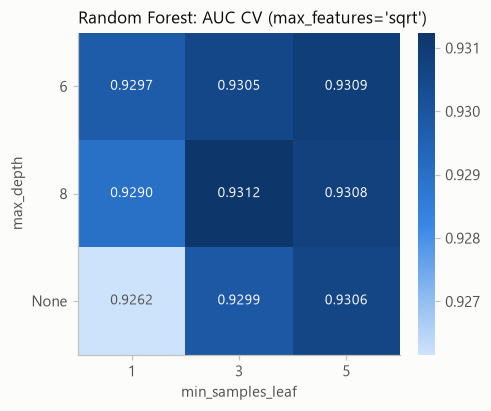

In [12]:
rf = cv_res[(cv_res["modelo"] == "RandomForestClassifier")
            & (cv_res["param_clf__max_features"] == grid.best_params_["clf__max_features"])].copy()
rf["max_depth"] = rf["param_clf__max_depth"].astype(str)
rf["min_samples_leaf"] = rf["param_clf__min_samples_leaf"].astype(int)
mapa = rf.pivot_table(index="max_depth", columns="min_samples_leaf", values="mean_test_roc_auc")

fig, ax = plt.subplots(figsize=(5.4, 3.8))
vmin, vmax = mapa.values.min(), mapa.values.max()
im = ax.imshow(mapa.values, cmap=BLUE_RAMP, vmin=vmin, vmax=vmax)
ax.set_xticks(range(mapa.shape[1]), mapa.columns)
ax.set_yticks(range(mapa.shape[0]), mapa.index)
ax.set_xlabel("min_samples_leaf")
ax.set_ylabel("max_depth")
ax.grid(False)
for i in range(mapa.shape[0]):
    for j in range(mapa.shape[1]):
        v = mapa.values[i, j]
        oscuro = (v - vmin) / (vmax - vmin) > 0.45  # texto blanco sobre celdas oscuras
        ax.text(j, i, f"{v:.4f}", ha="center", va="center", fontsize=9, color="white" if oscuro else INK_2)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).outline.set_visible(False)
ax.set_title(f"Random Forest: AUC CV (max_features='{grid.best_params_['clf__max_features']}')", loc="left")
plt.show()

## 4. Diagnóstico de sobreajuste y estabilidad

### 4.1 AUC por fold: entrenamiento contra validación

In [13]:
folds = pd.DataFrame({
    "AUC entrenamiento": [cv_res.loc[mejor, f"split{i}_train_roc_auc"] for i in range(5)],
    "AUC validación": [cv_res.loc[mejor, f"split{i}_test_roc_auc"] for i in range(5)],
    "Accuracy validación": [cv_res.loc[mejor, f"split{i}_test_accuracy"] for i in range(5)],
}, index=[f"fold {i + 1}" for i in range(5)])
folds["brecha"] = folds["AUC entrenamiento"] - folds["AUC validación"]
folds.loc["media"] = folds.mean()
display(folds.round(4))

,AUC entrenamiento,AUC validación,Accuracy validación,brecha
fold 1,0.9833,0.9328,0.8435,0.0505
fold 2,0.9866,0.8831,0.7891,0.1035
fold 3,0.9819,0.9454,0.8639,0.0365
fold 4,0.9816,0.9547,0.8912,0.0268
fold 5,0.9841,0.9402,0.8699,0.0439
media,0.9835,0.9312,0.8515,0.0522


### 4.2 Curva de aprendizaje

Igual que en el cap. 2.7 del libro, se estima el AUC de entrenamiento y de validación (CV-5, solo con el conjunto de entrenamiento) al aumentar el número de pacientes.

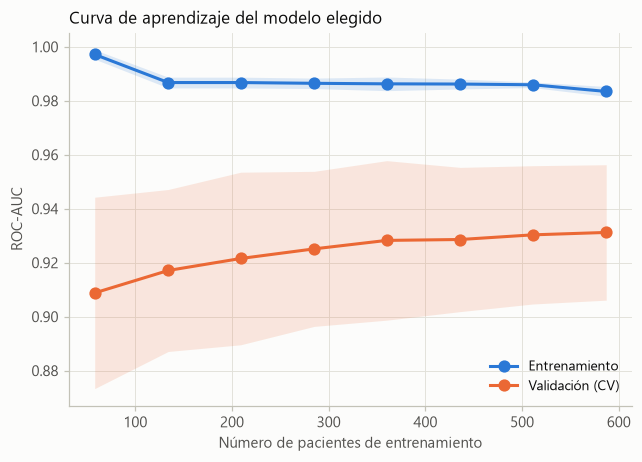

,AUC entrenamiento,AUC validación,d.e. validación
pacientes,,,
58,0.9972,0.9088,0.0355
134,0.9867,0.9171,0.0300
209,0.9868,0.9216,0.0320
285,0.9865,0.9251,0.0287
360,0.9863,0.9283,0.0296
436,0.9862,0.9286,0.0267
511,0.9859,0.9303,0.0256
587,0.9835,0.9312,0.0251


In [14]:
tamanos, auc_train, auc_val = learning_curve(
    grid.best_estimator_, X_train, y_train, cv=get_cv(), scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1)

fig, ax = plt.subplots(figsize=(6.6, 4.4))
plot_learning_curve(tamanos, auc_train, auc_val, ax=ax, title="Curva de aprendizaje del modelo elegido")
plt.show()
display(pd.DataFrame({"pacientes": tamanos, "AUC entrenamiento": auc_train.mean(axis=1),
                      "AUC validación": auc_val.mean(axis=1),
                      "d.e. validación": auc_val.std(axis=1)}).set_index("pacientes").round(4))

### 4.3 Validación cruzada anidada (cap. 9.2.6)

El `best_score_` de `GridSearchCV` es optimista: es el máximo entre todas las combinaciones evaluadas sobre los mismos folds. La validación cruzada anidada estima el desempeño del **procedimiento de búsqueda de la sección 3** (elegir modelo, escalado e hiperparámetros entre los finalistas): un bucle externo de 5 folds deja fuera una parte del entrenamiento y, en cada vuelta, un `GridSearchCV` interno repite toda la búsqueda solo con el resto. El conjunto de prueba no participa.

Una salvedad: la preselección de la etapa 1 (qué familias pasan y alrededor de qué valores se centran las grillas) usó los mismos datos de entrenamiento y queda fuera de este bucle, así que la estimación anidada todavía puede ser levemente optimista. El conjunto de prueba, que no intervino en ninguna de esas decisiones, es la referencia final.

In [15]:
busqueda_interna = GridSearchCV(build_pipeline(LogisticRegression()), param_grid, cv=get_cv(),
                                scoring="roc_auc", n_jobs=-1)
anidada = cross_validate(busqueda_interna, X_train, y_train, cv=get_cv(random_state=RANDOM_STATE + 1),
                         scoring=["roc_auc", "accuracy"], return_estimator=True)

elegidos = [type(b.best_estimator_.named_steps["clf"]).__name__ for b in anidada["estimator"]]
display(pd.DataFrame({"modelo elegido por la búsqueda interna": elegidos,
                      "AUC (fold externo)": anidada["test_roc_auc"],
                      "Accuracy (fold externo)": anidada["test_accuracy"]},
                     index=[f"fold externo {i + 1}" for i in range(5)]).round(4))
print(f"AUC CV anidada = {anidada['test_roc_auc'].mean():.4f} ± {anidada['test_roc_auc'].std():.4f}"
      f" | Accuracy = {anidada['test_accuracy'].mean():.4f} ± {anidada['test_accuracy'].std():.4f}")

,modelo elegido por la búsqueda interna,AUC (fold externo),Accuracy (fold externo)
fold externo 1,GradientBoostingClassifier,0.9259,0.8707
fold externo 2,RandomForestClassifier,0.9022,0.8435
fold externo 3,BaggingClassifier,0.9265,0.8299
fold externo 4,GradientBoostingClassifier,0.9214,0.8571
fold externo 5,GradientBoostingClassifier,0.9299,0.8151


AUC CV anidada = 0.9212 ± 0.0099 | Accuracy = 0.8433 ± 0.0196


**Lectura del diagnóstico:**

- **Brecha entrenamiento-validación:** el AUC de entrenamiento es ≈ 0.98 en todos los folds y el de validación 0.931 en promedio (brecha de 0.052). Con el criterio del cap. 2.7 (brecha > 0.02) esto indicaría sobreajuste, pero en un Random Forest es esperable: cada árbol se ajusta casi perfectamente a su muestra *bootstrap*, así que el AUC "de entrenamiento" siempre es muy alto. Lo relevante es el desempeño con datos no vistos, y ahí es el mejor candidato.
- **Estabilidad entre folds:** el AUC de validación va de 0.883 (fold 2) a 0.955 (fold 4). Con folds de unos 147 pacientes la incertidumbre de una sola partición es grande; por eso se reporta media ± desviación.
- **Curva de aprendizaje:** el AUC de validación sube de forma sostenida, de 0.909 con 58 pacientes a 0.931 con 587, y todavía no se estabiliza del todo: más datos probablemente mejorarían algo el modelo. La brecha baja de 0.088 a 0.052 al crecer el conjunto.
- **Validación cruzada anidada:** estima 0.921 ± 0.010 para el procedimiento de búsqueda, algo por debajo del `best_score_` (0.931). Esa diferencia (~0.010) es el optimismo de quedarse con el máximo de 144 combinaciones. La búsqueda interna elige Gradient Boosting en 3 de los 5 folds externos, Random Forest en 1 y *bagging* en 1: los mejores candidatos están empatados y la elección entre ellos depende del azar de la partición.

## 5. Evaluación final en el conjunto de prueba

El conjunto de prueba se usa solo para **reportar**: ninguna decisión (preprocesamiento, modelo, hiperparámetros ni umbral) depende de él. En el ranking del notebook 1 (sección 8) ya se había reportado el AUC en prueba de esta misma configuración; aquí se completa la evaluación del Pipeline final con el intervalo de confianza, la matriz de confusión, la curva ROC y el reporte por clase. El umbral de decisión es 0.5, el mismo que usa la API.

In [16]:
modelo_final = grid.best_estimator_
nombre_modelo = type(modelo_final.named_steps["clf"]).__name__
proba_test = modelo_final.predict_proba(X_test)[:, 1]
pred_test = modelo_final.predict(X_test)

metricas = classification_metrics(y_test, pred_test, proba_test)
ic_bajo, ic_alto = bootstrap_auc_ci(y_test, proba_test)
resumen_metricas = pd.DataFrame({
    "valor en prueba": [metricas["auc"], metricas["accuracy"], metricas["precision"],
                        metricas["recall"], metricas["specificity"], metricas["f1"]],
}, index=["AUC", "Accuracy", "Precisión (VPP)", "Sensibilidad (recall)", "Especificidad", "F1"])
display(resumen_metricas.round(4))
print(f"IC bootstrap 95 % del AUC en prueba: {ic_bajo:.3f} a {ic_alto:.3f}")
print(f"Referencias: AUC CV = {grid.best_score_:.4f} | AUC CV anidada = {anidada['test_roc_auc'].mean():.4f}")
print()
print(classification_report(y_test, pred_test, target_names=["Sin enfermedad", "Con enfermedad"], digits=3))

,valor en prueba
AUC,0.9284
Accuracy,0.8913
Precisión (VPP),0.8796
Sensibilidad (recall),0.9314
Especificidad,0.8415
F1,0.9048


IC bootstrap 95 % del AUC en prueba: 0.886 a 0.963
Referencias: AUC CV = 0.9312 | AUC CV anidada = 0.9212

                precision    recall  f1-score   support

Sin enfermedad      0.908     0.841     0.873        82
Con enfermedad      0.880     0.931     0.905       102

      accuracy                          0.891       184
     macro avg      0.894     0.886     0.889       184
  weighted avg      0.892     0.891     0.891       184



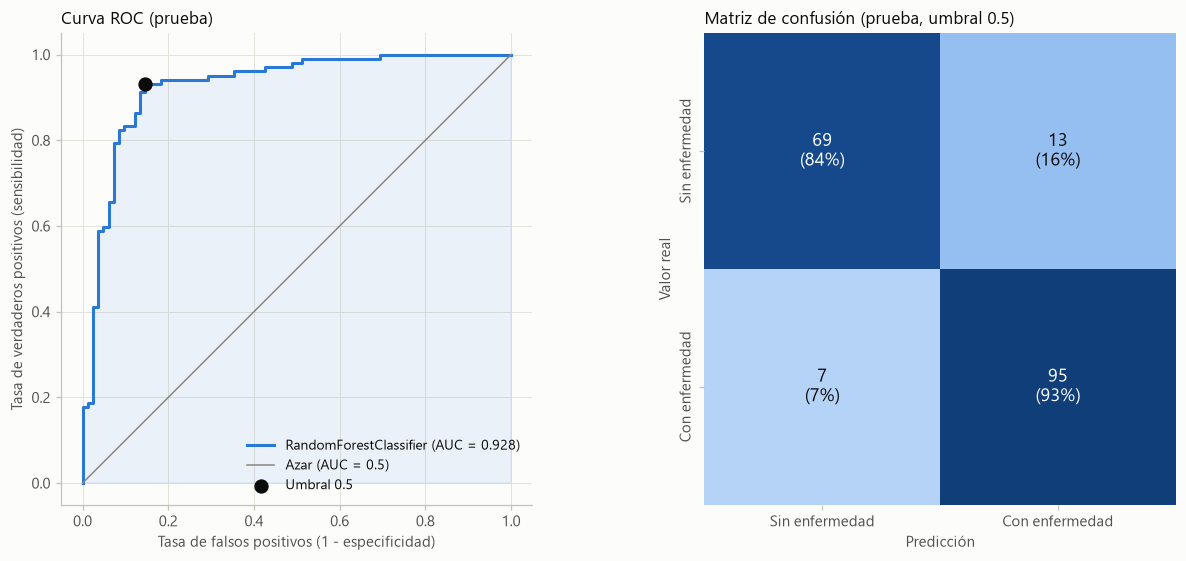

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
plot_roc(y_test, proba_test, nombre_modelo, ax=axes[0])
axes[0].set_title("Curva ROC (prueba)", loc="left")
plot_confusion(y_test, pred_test, ax=axes[1], title="Matriz de confusión (prueba, umbral 0.5)")
fig.tight_layout()
plt.show()

**Lectura:** en los 184 pacientes de prueba el modelo alcanza **AUC = 0.928** (IC 95 %: 0.886 a 0.963) y **accuracy = 0.891**, coherente con las estimaciones previas (AUC de CV 0.931 y de CV anidada 0.921): no hay señales de que la elección se haya sobreajustado a los datos de entrenamiento. Con el umbral de 0.5:

- detecta a **95 de 102 enfermos** (sensibilidad 0.931) y deja pasar 7 (falsos negativos);
- descarta correctamente a **69 de 82 sanos** (especificidad 0.841), con 13 falsas alarmas;
- de cada 100 pacientes que marca como enfermos, unos 88 lo están (precisión 0.880).

### 5.1 Umbral de decisión

En un tamizaje clínico suele preferirse no dejar pasar enfermos (alta sensibilidad), aunque aumenten las falsas alarmas. El umbral **no** debe elegirse con el conjunto de prueba (sería otra fuga); se analiza con predicciones *out-of-fold* del entrenamiento (`cross_val_predict`), donde cada paciente se predice con un modelo que no lo vio.

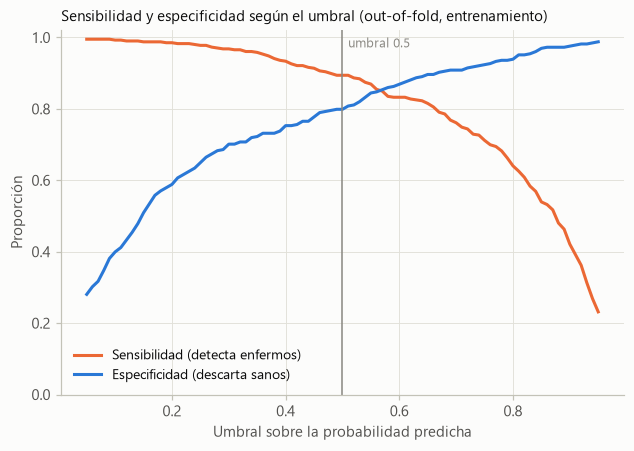

,sensibilidad,especificidad,accuracy
umbral,,,
0.3,0.968,0.701,0.849
0.4,0.933,0.753,0.853
0.5,0.894,0.799,0.851
0.6,0.833,0.869,0.849


In [18]:
proba_oof = cross_val_predict(clone(modelo_final), X_train, y_train, cv=get_cv(),
                              method="predict_proba", n_jobs=-1)[:, 1]
fig, ax = plt.subplots(figsize=(6.6, 4.3))
plot_threshold_tradeoff(y_train, proba_oof, ax=ax)
ax.set_title("Sensibilidad y especificidad según el umbral (out-of-fold, entrenamiento)", loc="left", fontsize=10)
plt.show()

filas = []
for umbral in (0.3, 0.4, 0.5, 0.6):
    pred = (proba_oof > umbral).astype(int)
    m = classification_metrics(y_train, pred, proba_oof)
    filas.append({"umbral": umbral, "sensibilidad": m["recall"], "especificidad": m["specificity"],
                  "accuracy": m["accuracy"]})
display(pd.DataFrame(filas).set_index("umbral").round(3))

**Lectura:** bajar el umbral de 0.5 a 0.4 sube la sensibilidad *out-of-fold* de 0.894 a 0.933, a costa de la especificidad (de 0.799 a 0.753), con una *accuracy* prácticamente igual. La API conserva el umbral de 0.5 del enunciado y lo informa en cada respuesta (campo `threshold`). Si el equipo clínico prioriza no dejar pasar enfermos, 0.4 es una alternativa razonable, y esta tabla, calculada solo con el entrenamiento, es la base correcta para decidirlo.

### 5.2 ¿El modelo elegido supera a los demás finalistas?

Para cada familia se reentrena su mejor configuración de la búsqueda (sección 3) con todo el entrenamiento y se compara con el modelo final mediante el test de DeLong pareado sobre los mismos 184 pacientes de prueba (cap. 9.9). Como son varias comparaciones a la vez, además del umbral usual de 0.05 se muestra la corrección de Bonferroni (0.05 dividido por el número de comparaciones). Es un análisis descriptivo: el modelo ya quedó elegido en la sección 3 y este resultado no lo cambia.

In [19]:
proba_finalistas = {nombre_modelo: proba_test}
for familia, fila in mejor_por_modelo.iterrows():
    if familia == nombre_modelo:
        continue
    # clone() crea copias nuevas: no se modifica el objeto guardado en la grilla
    estimador = clone(build_pipeline(LogisticRegression()).set_params(**fila["params"]))
    proba_finalistas[familia] = estimador.fit(X_train, y_train).predict_proba(X_test)[:, 1]

comparacion_finalistas = delong_vs_reference(y_test, proba_finalistas, nombre_modelo)
alfa_bonferroni = 0.05 / len(comparacion_finalistas)
comparacion_finalistas["significativa (Bonferroni)"] = np.where(
    comparacion_finalistas["p_value"] < alfa_bonferroni, "Sí", "No")
display(comparacion_finalistas.sort_values("p_value").round(4))
print(f"Comparaciones: {len(comparacion_finalistas)} | umbral de Bonferroni: {alfa_bonferroni:.4f}")

,delta_auc,magnitud,z,p_value,significativa,interpretacion,significativa (Bonferroni)
comparacion,,,,,,,
RandomForestClassifier vs DecisionTreeClassifier,0.0323,moderada,2.8032,0.0051,Sí,Diferencia significativa y relevante,No
RandomForestClassifier vs MLPClassifier,-0.0063,trivial,-0.9622,0.3360,No,Diferencia trivial y no significativa,No
RandomForestClassifier vs KNeighborsClassifier,-0.0071,trivial,-0.8435,0.3990,No,Diferencia trivial y no significativa,No
RandomForestClassifier vs GaussianNB,0.0039,trivial,0.4477,0.6543,No,Diferencia trivial y no significativa,No
RandomForestClassifier vs BaggingClassifier,-0.0024,trivial,-0.3385,0.7350,No,Diferencia trivial y no significativa,No
RandomForestClassifier vs LogisticRegression,-0.0025,trivial,-0.2918,0.7704,No,Diferencia trivial y no significativa,No
RandomForestClassifier vs BernoulliNB,0.0020,trivial,0.2804,0.7792,No,Diferencia trivial y no significativa,No
RandomForestClassifier vs AdaBoostClassifier,0.0014,trivial,0.1386,0.8898,No,Diferencia trivial y no significativa,No
RandomForestClassifier vs SVC,-0.0010,trivial,-0.1303,0.8964,No,Diferencia trivial y no significativa,No


Comparaciones: 10 | umbral de Bonferroni: 0.0050


**Lectura:** frente al mejor modelo de cada una de las otras 10 familias, Random Forest solo difiere en prueba del árbol de decisión individual (ΔAUC = 0.032, moderada, p = 0.0051). Esa diferencia es significativa al 5 %, pero no tras la corrección de Bonferroni (umbral 0.05/10 = 0.005), aunque sigue siendo la única de magnitud relevante. Todas las demás son triviales (|ΔAUC| < 0.01, p ≥ 0.34): incluso la regresión logística, el modelo más simple e interpretable, logra en prueba un AUC levemente mayor (ΔAUC = −0.0025, p = 0.77).

Se mantiene Random Forest porque el criterio de selección, definido antes de mirar la prueba, es el AUC de validación cruzada: cambiar de modelo por este resultado sería elegir con el conjunto de prueba. Aun así, el resultado es útil para el despliegue: si se prioriza la interpretabilidad (coeficientes y *odds ratios* explicables al equipo médico), la regresión logística es una alternativa con desempeño equivalente.

## 6. Etapa 3 — Exportación del modelo para la API

Se guarda el Pipeline completo (`grid.best_estimator_`: imputación, codificación, escalado y clasificador). Así la API recibe los datos crudos, tal como vienen en el CSV, y aplica exactamente las mismas transformaciones que se aprendieron con el entrenamiento.

- `app/model.joblib`: lo carga la API (`app/api.py`) y lo copia el `Dockerfile` (`COPY app/ ./app/`).
- `model.joblib` en la raíz: copia para respetar la estructura de la Etapa 0.
- `app/model_metadata.json`: trazabilidad (versiones, partición y métricas). La prueba `tests/test_model.py` del repositorio verifica con la huella de la partición que el control de calidad se hace con los mismos pacientes de prueba.

In [20]:
APP_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(modelo_final, MODEL_PATH)       # equivale a joblib.dump(grid.best_estimator_, "app/model.joblib")
joblib.dump(modelo_final, ROOT_MODEL_PATH)  # copia en la raíz (estructura de la Etapa 0)

metadata = {
    "modelo": type(modelo_final.named_steps["clf"]).__name__,
    "estimador": " ".join(str(modelo_final.named_steps["clf"]).split()),
    "hiperparametros": {k: str(v) for k, v in grid.best_params_.items() if k != "clf"},
    "entrenado": datetime.now().isoformat(timespec="seconds"),
    "versiones": {"python": platform.python_version(), "scikit-learn": sklearn.__version__,
                  "numpy": np.__version__, "pandas": pd.__version__},
    "datos": {"archivo": "data/heart.csv", "filas": len(df),
              "sha256": hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()},
    "split": {"test_size": TEST_SIZE, "random_state": RANDOM_STATE, "estratificado_por": TARGET,
              "n_train": len(X_train), "n_test": len(X_test), "fingerprint": split_fingerprint(X_test)},
    "metricas": {"cv_auc": round(grid.best_score_, 4),
                 "cv_auc_std": round(cv_res.loc[mejor, "std_test_roc_auc"], 4),
                 "cv_accuracy": round(cv_res.loc[mejor, "mean_test_accuracy"], 4),
                 "nested_cv_auc": round(anidada["test_roc_auc"].mean(), 4),
                 "test_auc": round(metricas["auc"], 4),
                 "test_auc_ic95": [round(ic_bajo, 4), round(ic_alto, 4)],
                 "test_accuracy": round(metricas["accuracy"], 4),
                 "test_sensibilidad": round(metricas["recall"], 4),
                 "test_especificidad": round(metricas["specificity"], 4)},
    "umbral": 0.5,
    "features": FEATURES,
}
METADATA_PATH.write_text(json.dumps(metadata, indent=2, ensure_ascii=False), encoding="utf-8")

recargado = joblib.load(MODEL_PATH)
assert np.array_equal(recargado.predict_proba(X_test), modelo_final.predict_proba(X_test))
print(f"Modelo guardado en app/{MODEL_PATH.name} ({MODEL_PATH.stat().st_size / 1e6:.1f} MB) "
      f"y copia en ./{ROOT_MODEL_PATH.name}")
print("Recarga verificada: predicciones idénticas.")
print(json.dumps(metadata["metricas"], indent=2))

Modelo guardado en app/model.joblib (2.7 MB) y copia en ./model.joblib
Recarga verificada: predicciones idénticas.
{
  "cv_auc": 0.9312,
  "cv_auc_std": 0.0251,
  "cv_accuracy": 0.8515,
  "nested_cv_auc": 0.9212,
  "test_auc": 0.9284,
  "test_auc_ic95": [
    0.886,
    0.9632
  ],
  "test_accuracy": 0.8913,
  "test_sensibilidad": 0.9314,
  "test_especificidad": 0.8415
}


### 6.1 Uso del modelo exportado, igual que en la API

La API (`POST /predict`) recibe las 11 variables de un paciente, arma un `DataFrame` con las columnas en el orden del dataset y aplica el Pipeline guardado. Esta es la misma operación con el paciente de ejemplo de la documentación de la API:

In [21]:
paciente = {"Age": 54, "Sex": "M", "ChestPainType": "ASY", "RestingBP": 140, "Cholesterol": 239, "FastingBS": 0,
            "RestingECG": "Normal", "MaxHR": 160, "ExerciseAngina": "N", "Oldpeak": 1.2, "ST_Slope": "Flat"}
proba = float(joblib.load(MODEL_PATH).predict_proba(pd.DataFrame([paciente], columns=FEATURES))[0, 1])
print({"heart_disease_probability": round(proba, 4), "prediction": int(proba > 0.5), "threshold": 0.5})

{'heart_disease_probability': 0.7764, 'prediction': 1, 'threshold': 0.5}


### 6.2 Despliegue y operación (Etapas 3 a 5)

El resto del ciclo de MLOps está implementado en el repositorio ([RubenEsg/Machine-Learning-Tarea-2](https://github.com/RubenEsg/Machine-Learning-Tarea-2)) y documentado en los capítulos de las etapas 3 a 6 del Jupyter Book:

| Etapa | Archivos | Qué hace |
|---|---|---|
| 3. API y Docker | `app/api.py`, `docker/Dockerfile`, `docker/requirements.txt` | API FastAPI con `/predict` (acepta campos con nombre o el formato `{"features": [...]}` del enunciado), `/health` y `/model-info`; imagen `python:3.10-slim` con las mismas versiones de scikit-learn y numpy con que se entrenó el modelo |
| 4. Kubernetes | `k8s/deployment.yaml`, `k8s/service.yaml` | 2 réplicas con *probes* sobre `/health` y un `Service` tipo `LoadBalancer` (puerto 80 → 8000) |
| 5. Integración continua | `.github/workflows/ci.yml`, `tests/` | en cada *push*: flake8, pruebas con pytest (API y validación de entradas, partición de los datos y control de calidad del modelo) y construcción de la imagen Docker con una prueba de humo |
| 6. Monitoreo | `monitoring/drift_report.py` | reporte de deriva de Evidently contra cualquier lote de pacientes recibidos por la API |

## 7. Etapa 6 — Monitoreo de deriva de datos con Evidently

La deriva de datos (*data drift*) ocurre cuando la distribución de los datos que llegan a producción se aleja de la de entrenamiento; si eso pasa, las métricas estimadas aquí dejan de ser confiables. Como pide el enunciado, la referencia es `X_train` y los datos actuales son `X_test`. Se usa `build_drift_report` (sección 1.2), con la API actual de Evidently, y se declara qué columnas son numéricas y cuáles categóricas (`FastingBS`, que es 0/1, se trata como categórica).

In [22]:
snapshot = build_drift_report(reference=X_train, current=X_test, output_path=DRIFT_REPORT_PATH)
resumen_deriva, global_deriva = drift_summary(snapshot)
display(resumen_deriva.round(4))
print(f"Columnas con deriva: {global_deriva['columnas_con_deriva']} de {len(resumen_deriva)} "
      f"(el reporte declara deriva del dataset si al menos el {global_deriva['umbral_proporcion']:.0%} de las columnas deriva)")
print("¿Deriva del dataset?", "Sí" if global_deriva["deriva_del_dataset"] else "No")
print("Reporte HTML guardado en ./" + DRIFT_REPORT_PATH.name)

,prueba,valor,umbral,deriva
columna,,,,
Age,K-S p_value,0.0721,0.05,No
RestingBP,K-S p_value,0.5388,0.05,No
Cholesterol,K-S p_value,0.0174,0.05,Sí
MaxHR,K-S p_value,0.6082,0.05,No
Oldpeak,K-S p_value,0.3229,0.05,No
Sex,Z-test p_value,0.8899,0.05,No
ChestPainType,chi-square p_value,0.1989,0.05,No
RestingECG,chi-square p_value,0.5173,0.05,No
ExerciseAngina,Z-test p_value,0.5722,0.05,No


Columnas con deriva: 1 de 11 (el reporte declara deriva del dataset si al menos el 50% de las columnas deriva)
¿Deriva del dataset? No
Reporte HTML guardado en ./drift_report.html


**Lectura:** solo 1 de las 11 columnas aparece con deriva (`Cholesterol`, p = 0.017), muy lejos del umbral del 50 % para declarar deriva del dataset. Es lo esperable por azar: con 11 pruebas al 5 % se esperan en promedio unas 0.55 falsas alarmas. La señal en `Cholesterol` viene de los ceros ("no medido"): la prueba de Kolmogorov-Smirnov es sensible al salto en 0, y la proporción de colesteroles no medidos quedó en 17.6 % en entrenamiento contra 23.4 % en prueba (la estratificación se hizo por `HeartDisease`, no por esta variable). Conclusión: la partición aleatoria estratificada produce un conjunto de prueba **representativo** del entrenamiento, y `drift_report.html` queda como línea base del monitoreo.

### 7.1 ¿Detecta el monitor una deriva real? Partición secuencial como "otro hospital"

Para comprobar que el monitor sí reacciona, se simula lo que pasaría si el modelo recibiera pacientes de hospitales distintos a los de entrenamiento: la referencia son las primeras 734 filas del archivo (ordenado por hospital) y los datos actuales las últimas 184. Es exactamente la partición que se obtendría con `train_test_split(..., shuffle=False)`. Aquí no se entrena ningún modelo; solo se comparan distribuciones.

In [23]:
secuencial = df[FEATURES]
ref_seq, act_seq = secuencial.iloc[:len(X_train)], secuencial.iloc[len(X_train):]
snap_seq = build_drift_report(ref_seq, act_seq, MONITORING_DIR / "drift_particion_secuencial.html")
resumen_seq, global_seq = drift_summary(snap_seq)

comparacion = pd.DataFrame({
    "prueba": resumen_deriva["prueba"],
    "p-valor (partición aleatoria)": resumen_deriva["valor"],
    "deriva (aleatoria)": resumen_deriva["deriva"],
    "p-valor (partición secuencial)": resumen_seq["valor"],
    "deriva (secuencial)": resumen_seq["deriva"],
})
display(comparacion.round(4))
print(f"Partición aleatoria estratificada: {global_deriva['columnas_con_deriva']} de 11 columnas con deriva")
print(f"Partición secuencial (sin barajar): {global_seq['columnas_con_deriva']} de 11 columnas con deriva "
      f"-> deriva del dataset: {'Sí' if global_seq['deriva_del_dataset'] else 'No'}")

,prueba,p-valor (partición aleatoria),deriva (aleatoria),p-valor (partición secuencial),deriva (secuencial)
columna,,,,,
Age,K-S p_value,0.0721,No,0.2355,No
RestingBP,K-S p_value,0.5388,No,0.5385,No
Cholesterol,K-S p_value,0.0174,Sí,0.0000,Sí
MaxHR,K-S p_value,0.6082,No,0.0000,Sí
Oldpeak,K-S p_value,0.3229,No,0.0063,Sí
Sex,Z-test p_value,0.8899,No,0.0010,Sí
ChestPainType,chi-square p_value,0.1989,No,0.0000,Sí
RestingECG,chi-square p_value,0.5173,No,0.0000,Sí
ExerciseAngina,Z-test p_value,0.5722,No,0.0158,Sí


Partición aleatoria estratificada: 1 de 11 columnas con deriva
Partición secuencial (sin barajar): 8 de 11 columnas con deriva -> deriva del dataset: Sí


**Lectura:** con la partición secuencial, **8 de las 11 columnas** presentan deriva (entre ellas `Cholesterol`, `MaxHR`, `ChestPainType` y `RestingECG`, con p < 0.001) y Evidently declara deriva del dataset. Esto confirma dos cosas: (1) el monitor sí detecta un cambio de población como el de recibir pacientes de otro hospital, y (2) partir sin barajar habría producido un conjunto de prueba con una distribución distinta a la del entrenamiento, que no mediría lo que se quiere medir. El reporte de este ejemplo queda en `monitoring/drift_particion_secuencial.html`.

**Uso en producción:** el script `monitoring/drift_report.py` del repositorio genera el mismo reporte comparando el entrenamiento con cualquier lote de pacientes recibidos por la API (`--current lote.csv`); con `--fail-on-drift` termina con código de error si hay deriva, para automatizarlo (por ejemplo, en una tarea programada o en el CI).

## 8. Conclusiones

1. **División antes del escalado:** la partición es la misma del notebook 1 (huella `6f866816e8c7`) y todo el preprocesamiento vive dentro del Pipeline; se comprobó que el escalador solo conoce los mínimos y máximos del entrenamiento.
2. **Pipeline + GridSearchCV:** una única búsqueda sobre 11 familias de scikit-learn (144 combinaciones × 5 folds) eligió modelo, escalado e hiperparámetros: Random Forest (`max_depth=8`, `min_samples_leaf=3`, `max_features="sqrt"`) con AUC de CV de 0.931 ± 0.025, sin óptimos en el borde de la grilla.
3. **Estimación honesta del desempeño:** la validación cruzada anidada (0.921 ± 0.010) y el conjunto de prueba (**AUC = 0.928**, IC 95 % de 0.886 a 0.963; **accuracy = 0.891**) coinciden. El modelo detecta al 93 % de los enfermos con una especificidad del 84 %.
4. **Matices:** el modelo elegido es estadísticamente equivalente al mejor de cada una de las demás familias salvo el árbol de decisión individual; la regresión logística es una alternativa igual de buena y más interpretable (DeLong, p = 0.77). La curva de aprendizaje sugiere que más datos mejorarían el modelo.
5. **Despliegue y monitoreo (etapas 3 a 6):** el Pipeline completo se exporta a `app/model.joblib` y lo sirve la API FastAPI en Docker y Kubernetes, con integración continua en GitHub Actions. Evidently no encuentra deriva entre entrenamiento y prueba (1 de 11 variables, lo esperable por azar) y sí la detecta en una población de otro hospital (8 de 11).
6. **Limitaciones y trabajo futuro:** los datos provienen de cinco hospitales con distinta prevalencia y la falta de colesterol depende del origen, así que el modelo debe validarse externamente con la población donde se vaya a usar. Quedan como líneas futuras la calibración de probabilidades, la interpretación de las predicciones (por ejemplo con SHAP o LIME), la elección del umbral junto con el equipo clínico y el monitoreo continuo de las solicitudes que reciba la API. El modelo es un apoyo académico y no reemplaza el criterio médico.